In [1]:
import sys
# sys.path.append(r'C:\Users\edwar\Documents\LabStuff\ibllib\brainbox\io')
#sys.path.append(r'C:\Users\IBL\Documents\ibl_analysis\ONE\one')
import matplotlib.pyplot as plt
import numpy as np
#from brainbox.io.one import load_wheel_reaction_times
import brainbox.behavior.wheel as wh
from ibllib.io.raw_data_loaders import *
from ibllib.pipes import *
from ibllib.io.extractors.bpod_trials import *
from one.api import ONE
from one.alf.io import *
from ibllib.io.extractors.base import BaseBpodTrialsExtractor, run_extractor_classes
# from ibllib.io.extractors.camera import CameraTimestampsBpod
# from ibllib.io.extractors.ephys_fpga import extract_wheel_moves
from ibllib.io.extractors.training_wheel import extract_first_movement_times
#from localAlf import load_wheel_reaction_times_local
from brainbox.behavior.training import *
import scipy.io.wavfile as wavfile
from scipy import signal
from ScanImageTiffReader import ScanImageTiffReader
import json
import ast
import math

# Add murphlib path
sys.path.append(r'C:\Users\mcter\OneDrive\Documents\SchoolCourses\NSCI448\Code\ibllib')
from murphlib.tools import *

c:\users\mcter\onedrive\documents\schoolcourses\nsci448\code\ibllib\ibllib\io\raw_data_loaders.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [2]:
mouse_path = r'C:\Users\mcter\OneDrive\Documents\SchoolCourses\NSCI448\Code\test_behavior'
session_path = mouse_path

# trials, wheel, output_files = extract_all(session_path, save=True)
trials = extract_all(session_path, save=False)[0]

pavlovian


In [3]:
# trials['table'] = trials['table'][2:]
# trials['table'] = trials['table'].reset_index(drop=True)

trials['table']

# ruleCueTrigger_times = time when tone command was delivered
# ruleCue_times = time when tone command actually occured
# feedback_times = time when reward was given (or not)
# itiIn_times = time when ITI began


,intervals_0,intervals_1,ruleCue_times,ruleCueTrigger_times,feedback_times,feedbackType,rewardVolume,iti_dur,itiIn_times,trial_feedback_type
0,0.0000,8.738602,4.2075,4.1885,4.6885,1,0.5,4.0000,4.7385,1
1,8.7951,13.876502,8.8271,8.7951,9.2951,1,0.5,4.5313,9.3451,0
2,13.9356,20.562802,13.9667,13.9356,14.4356,1,0.5,6.0771,14.4856,0
3,20.6277,28.811402,20.6586,20.6277,21.1277,-1,0.0,7.6336,21.1777,-1
4,28.8806,34.490902,28.9106,28.8806,29.3806,1,0.5,5.0602,29.4306,1
5,34.6179,41.736302,34.6503,34.6179,35.1179,1,0.5,6.5683,35.1679,1
6,41.8009,49.509402,41.8382,41.8009,42.3009,1,0.5,7.1584,42.3509,1
7,49.5754,55.702603,49.6102,49.5754,50.0754,1,0.5,5.5771,50.1254,0
8,55.7655,62.243003,55.7980,55.7655,56.2655,1,0.5,5.9274,56.3155,0
9,62.3044,68.368502,62.3378,62.3044,62.8044,1,0.5,5.5140,62.8544,0


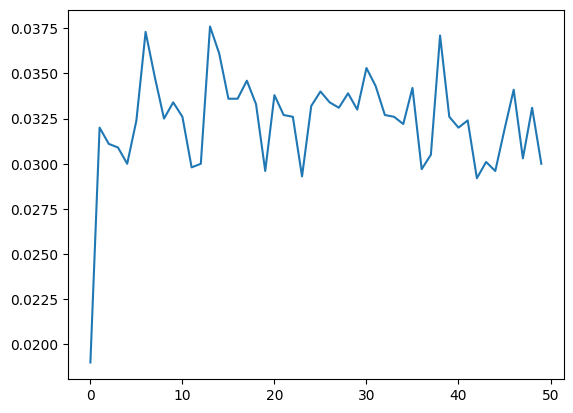

In [4]:
# fig, axes = plt.subplots(1,2)
# axes[0].plot(np.array(trials['table']['stimOn_times'])-np.array(trials['table']['stimOnTrigger_times']))
# axes[1].plot(np.array(trials['table']['ruleCue_times'])-np.array(trials['table']['ruleCueTrigger_times']))

plt.plot(np.array(trials['table']['ruleCue_times']) - np.array(trials['table']['ruleCueTrigger_times']))
plt.show()

In [5]:
# trials['table']['stimOn_times'] = np.where(trials['table']['stimOn_times'] < trials['table']['stimOnTrigger_times'],
#                                            trials['table']['stimOnTrigger_times']+0.06,
#                                            trials['table']['stimOn_times'])
trials['table']['ruleCue_times'] = np.where(trials['table']['ruleCue_times'] < trials['table']['ruleCueTrigger_times'],
                                            trials['table']['ruleCueTrigger_times']+np.median(trials['table']['ruleCue_times']-trials['table']['ruleCueTrigger_times']),
                                            trials['table']['ruleCue_times'])

# trials['table']['vis_stimOn_times'] = np.where(trials['table']['modality']==0,trials['table']['stimOnTrigger_times'],np.nan)
# trials['table']['vis_stimOn_times'] = trials['table']['vis_stimOn_times']+0.06
# trials['table']['vis_stimOn_times'] = np.where(trials['table']['modality']==0,trials['table']['stimOn_times'],np.nan)


# trials['table']['aud_stimOn_times'] = np.where(trials['table']['modality']==1,trials['table']['stimOnTrigger_times'],np.nan)
# trials['table']['aud_stimOn_times'] = trials['table']['aud_stimOn_times']+np.median(trials['table']['ruleCue_times']-trials['table']['ruleCueTrigger_times'])
# trials['table'].loc[trials['table']['feedbackType']==-1,'feedback_times'] = trials['table'].loc[trials['table']['feedbackType']==-1,'feedback_times']+np.median(trials['table']['ruleCue_times']-trials['table']['ruleCueTrigger_times'])
trials['table']

,intervals_0,intervals_1,ruleCue_times,ruleCueTrigger_times,feedback_times,feedbackType,rewardVolume,iti_dur,itiIn_times,trial_feedback_type
0,0.0000,8.738602,4.2075,4.1885,4.6885,1,0.5,4.0000,4.7385,1
1,8.7951,13.876502,8.8271,8.7951,9.2951,1,0.5,4.5313,9.3451,0
2,13.9356,20.562802,13.9667,13.9356,14.4356,1,0.5,6.0771,14.4856,0
3,20.6277,28.811402,20.6586,20.6277,21.1277,-1,0.0,7.6336,21.1777,-1
4,28.8806,34.490902,28.9106,28.8806,29.3806,1,0.5,5.0602,29.4306,1
5,34.6179,41.736302,34.6503,34.6179,35.1179,1,0.5,6.5683,35.1679,1
6,41.8009,49.509402,41.8382,41.8009,42.3009,1,0.5,7.1584,42.3509,1
7,49.5754,55.702603,49.6102,49.5754,50.0754,1,0.5,5.5771,50.1254,0
8,55.7655,62.243003,55.7980,55.7655,56.2655,1,0.5,5.9274,56.3155,0
9,62.3044,68.368502,62.3378,62.3044,62.8044,1,0.5,5.5140,62.8544,0


In [6]:
# cam_session_path = session_path
#cam_session_path = r'Z:\TM_Lab\Edward\Data\iblrig_data\Subjects\AG_R3\2023-11-14\001'
cam_session_path = r"C:\Users\mcter\OneDrive\Documents\SchoolCourses\NSCI448\Code\test_behavior"
cam_frame_data = load_camera_frameData(cam_session_path, camera = 'left')
cam_frame_count, cam_gpio =  load_embedded_frame_data(cam_session_path, label='left', raw=False)
embed_frame_counter = np.asarray(cam_frame_data['embeddedFrameCounter'])
embed_ts = np.asarray(cam_frame_data['embeddedTimeStamp'])
camera_ts = np.asarray(cam_frame_data['Timestamp'])
bpod_trials = rawio.load_data(cam_session_path, task_collection='raw_behavior_data')

In [7]:
cam_start_bpod_time = bpod_trials[0]['behavior_data']['Events timestamps']['Port1In'][0]-bpod_trials[0]['behavior_data']['Trial start timestamp']
cam_start_bpod_time

4.1885

In [8]:
def find_closest_index(value, list_of_values):
    # Find the index of the closest value in list_of_values
    return np.abs(np.array(list_of_values) - value).argmin()

table_for_video = trials['table'].copy()
for col in table_for_video.columns:
    if 'times' in col or 'intervals' in col:
        table_for_video[col] = table_for_video[col].subtract(cam_start_bpod_time)
        table_for_video[col] = table_for_video[col].apply(lambda x: embed_frame_counter[find_closest_index(x, embed_ts)])
table_for_video

,intervals_0,intervals_1,ruleCue_times,ruleCueTrigger_times,feedback_times,feedbackType,rewardVolume,iti_dur,itiIn_times,trial_feedback_type
0,0,275,2,0,30,1,0.5,4.0000,33,1
1,278,585,280,278,308,1,0.5,4.5313,311,0
2,589,989,590,589,619,1,0.5,6.0771,622,0
3,993,1487,995,993,1023,-1,0.0,7.6336,1026,-1
4,1491,1830,1493,1491,1521,1,0.5,5.0602,1524,1
5,1838,2267,1839,1838,1868,1,0.5,6.5683,1871,1
6,2271,2737,2274,2271,2301,1,0.5,7.1584,2305,1
7,2741,3111,2743,2741,2771,1,0.5,5.5771,2774,0
8,3115,3506,3117,3115,3145,1,0.5,5.9274,3148,0
9,3509,3876,3511,3509,3540,1,0.5,5.5140,3543,0


In [9]:
table_for_video.to_csv(cam_session_path+'\\table_for_video.csv', index=False)


In [10]:
frames_metadata_export_folder = os.path.join(mouse_path,'arm1')
frames_metadata_export_path = os.path.join(frames_metadata_export_folder, 'ca_img_frames_metadata.json')
img_path = find_tif_file(frames_metadata_export_folder)
try:
    with open(frames_metadata_export_path, 'r') as json_file:
        frames_metadata = json.load(json_file)
except:
    
    reader=ScanImageTiffReader(img_path)
    frames_metadata = []

    with ScanImageTiffReader(img_path) as reader:
        num_frames = reader.shape()[0]  # Assuming the first dimension represents frames
        
        for i in range(num_frames):
            description = reader.description(i)
            frame_metadata = {}  # Dictionary to hold this frame's metadata
            
            for line in description.split('\n'):
                if '=' in line:  # Ensure there's a key-value pair to parse
                    key, value = line.split('=', 1)  # Split by the first '='
                    key = key.strip()
                    
                    try:
                        # Safely evaluate the value string to the appropriate Python data type
                        # This works for numbers, lists, dictionaries, etc.
                        value = ast.literal_eval(value.strip())
                    except (ValueError, SyntaxError):
                        # If evaluation fails, keep the value as a string
                        value = value.strip()
                    
                    frame_metadata[key] = value
            
            frames_metadata.append(frame_metadata)
        
    with open(frames_metadata_export_path, 'w') as json_file:
        json.dump(frames_metadata, json_file)


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Users\\mcter\\OneDrive\\Documents\\SchoolCourses\\NSCI448\\Code\\test_behavior\\arm1'

In [ ]:
auxTrigger = []
frame_time = []
trigger_frame_num = []
# Iterate through each frame's metadata
if 'arm1' in img_path:
    trig_chan = 'auxTrigger0'
elif 'arm2' in img_path:
    trig_chan = 'auxTrigger1'
for frame_metadata in frames_metadata:
    frame_time.append(frame_metadata['frameTimestamps_sec'])
    # Check if 'auxTrigger0' exists and is not empty
    if trig_chan in frame_metadata and frame_metadata[trig_chan]:
        # Extend the all_auxTrigger0 list with the numbers from this frame's auxTrigger0
        if not auxTrigger:
            pass
        elif frame_metadata['frameNumbers'] in trigger_frame_num or frame_metadata['frameNumbers'] < max(trigger_frame_num)+5:
            continue
        print(frame_metadata)
        if type(frame_metadata[trig_chan]) == list:
            first_float = frame_metadata[trig_chan][0]
        elif type(frame_metadata[trig_chan]) == str:
            match = re.search(r'\d+\.\d+', frame_metadata['auxTrigger1'])
            if match:
                first_float = float(match.group())
            else:
                print(f"Missing trigger for framenum {frame_metadata['frameNumbers']}")
        else:
            print(f"cannot parse trigger for framenum {frame_metadata['frameNumbers']}")
        auxTrigger.append(first_float)
        trigger_frame_num.append(frame_metadata['frameNumbers'])
auxTrigger = np.array(auxTrigger)
len(auxTrigger)

{'frameNumbers': 454, 'acquisitionNumbers': 1, 'frameNumberAcquisition': 454, 'frameTimestamps_sec': 29.788300985, 'acqTriggerTimestamps_sec': -1.0, 'nextFileMarkerTimestamps_sec': -1.0, 'endOfAcquisition': 0, 'endOfAcquisitionMode': 0, 'dcOverVoltage': 0, 'epoch': '[2025  7 10 16 24 44.880]', 'auxTrigger0': [29.825601475, 29.82561268], 'auxTrigger1': [], 'auxTrigger2': [], 'auxTrigger3': [], 'I2CData': {}}
{'frameNumbers': 566, 'acquisitionNumbers': 1, 'frameNumberAcquisition': 566, 'frameTimestamps_sec': 37.154801755, 'acqTriggerTimestamps_sec': -1.0, 'nextFileMarkerTimestamps_sec': -1.0, 'endOfAcquisition': 0, 'endOfAcquisitionMode': 0, 'dcOverVoltage': 0, 'epoch': '[2025  7 10 16 24 44.880]', 'auxTrigger0': [37.16958789, 37.169599045], 'auxTrigger1': [], 'auxTrigger2': [], 'auxTrigger3': [], 'I2CData': {}}
{'frameNumbers': 662, 'acquisitionNumbers': 1, 'frameNumberAcquisition': 662, 'frameTimestamps_sec': 43.46928653, 'acqTriggerTimestamps_sec': -1.0, 'nextFileMarkerTimestamps_sec'

381

In [14]:
len(trials['table'])

50

In [15]:
ruleCue_times = np.array(trials['table']['ruleCue_times'])

array([-9.77650000e-05, -9.02900000e-05, -1.56450000e-05, -7.41250000e-05,
       -6.26850000e-05, -8.07650000e-05, -6.47700000e-05, -7.60750000e-05,
       -4.34750000e-05, -4.19200000e-05, -3.06800000e-05, -5.30450000e-05,
       -5.68000000e-05, -6.58800000e-05, -1.42600000e-05, -4.95200000e-05,
       -6.23400000e-05, -1.44660000e-04, -3.94700000e-05, -1.04150000e-05,
       -9.41700000e-05, -2.74100000e-05, -6.23750000e-05, -6.02700000e-05,
       -2.21350000e-05, -2.43150000e-05, -9.97900000e-05, -7.32150000e-05,
       -5.57450000e-05, -2.45650000e-05, -2.83000000e-05, -7.90700000e-05,
        2.67750000e-05, -1.29640000e-04, -4.09700000e-05, -8.37500000e-05,
       -2.86750000e-05, -9.23100001e-05, -3.97900000e-05, -1.08825000e-04,
       -2.64050001e-05, -6.81600000e-05, -5.14250000e-05, -6.96600000e-05,
       -2.74849999e-05, -3.93100000e-05, -5.24500000e-05, -4.89750000e-05,
       -9.31050000e-05,  1.01650000e-05,  1.57149999e-05, -1.15880000e-04,
       -7.44499999e-05, -

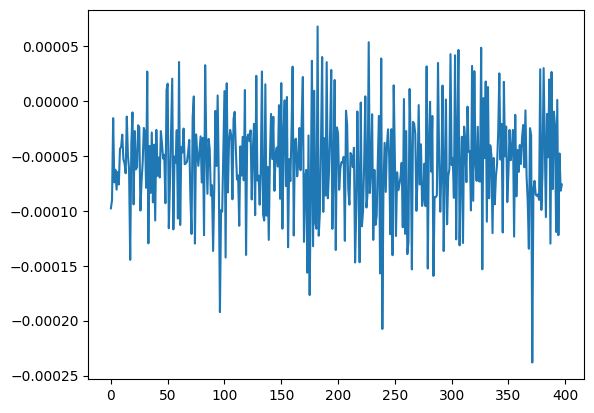

In [ ]:
realTriggers = auxTrigger[0:]
plt.plot(np.diff(ruleCue_times)-np.diff(realTriggers[:len(ruleCue_times)]))
np.diff(ruleCue_times)-np.diff(realTriggers[:len(ruleCue_times)])

In [ ]:
np.where(np.diff(ruleCue_times)-np.diff(realTriggers[:len(ruleCue_times)]) > 0.001)[0]

array([], dtype=int64)

In [ ]:
auxTrigger=auxTrigger[0:]


In [ ]:
auxTrigger = auxTrigger[:len(ruleCue_times)]

In [ ]:
print(f'first go cue in image: {auxTrigger[0]}')
print(f"first go cue in statemachine table: {trials['table']['ruleCue_times'][0]}")

first go cue in image: 12.95702651
first go cue in statemachine table: 4.9152999999999984


In [ ]:

statemachine_offset = auxTrigger[0]-trials['table']['ruleCue_times'][0] # time in s that state machine is leading the first goCueTime


In [ ]:
def find_closest_index(value, list_of_values):
    # Find the index of the closest value in list_of_values
    return np.abs(np.array(list_of_values) - value).argmin()


In [ ]:

table_for_img = trials['table'].copy()
for col in table_for_img.columns:
    if 'times' in col or 'intervals' in col:
        table_for_img[col] = table_for_img[col].add(statemachine_offset)
        table_for_img[col] = table_for_img[col].apply(lambda x: find_closest_index(x, frame_time))
        table_for_img[col] = table_for_img[col].apply(lambda x: np.nan if x == 0 else x)

In [ ]:
table_for_img

,intervals_0,intervals_1,ruleCue_times,ruleCueTrigger_times,response_times,choice,stimOnTrigger_times,stimOn_times,contrastLeft,contrastRight,feedback_times,feedbackType,rewardVolume,probabilityLeft,firstMovement_times,modality,omission,vis_stimOn_times,aud_stimOn_times
0,119,588,191,190,564,-1,203,206,NaN,1.0,564,1,3.0,0.50,561.0,0,0,206.0,NaN
1,609,751,619,619,727,1,634,635,1.0,NaN,727,1,3.0,0.50,727.0,0,0,635.0,NaN
2,772,857,781,780,803,1,792,793,NaN,0.5,803,-1,0.0,0.50,NaN,0,0,793.0,NaN
3,875,1019,883,883,965,1,939,940,NaN,0.5,966,-1,0.0,0.45,NaN,0,0,940.0,NaN
4,1040,1153,1079,1078,1129,1,1091,1092,0.5,NaN,1129,1,3.0,0.45,1079.0,0,0,1092.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,34671,35444,34681,34681,35390,-1,34712,34713,0.5,NaN,35391,-1,0.0,0.30,NaN,0,0,34713.0,NaN
201,35466,35620,35477,35476,35566,-1,35488,35489,0.5,NaN,35567,-1,0.0,0.35,NaN,0,0,35489.0,NaN
202,35640,36625,35649,35649,36572,0,35661,35662,NaN,0.5,36573,-1,0.0,0.40,NaN,0,0,35662.0,NaN
203,36649,36849,36657,36656,36825,1,36668,36669,0.5,NaN,36825,1,3.0,0.45,36824.0,0,0,36669.0,NaN


In [ ]:
#valid_trials=np.arange(0,314)
valid_trials = np.arange(0,len(table_for_img))
table_for_img = table_for_img.iloc[valid_trials]
table_for_img

,intervals_0,intervals_1,ruleCue_times,ruleCueTrigger_times,response_times,choice,stimOnTrigger_times,stimOn_times,contrastLeft,contrastRight,feedback_times,feedbackType,rewardVolume,probabilityLeft,firstMovement_times,modality,omission,vis_stimOn_times,aud_stimOn_times
0,54,235,132,131,211,1,143,NaN,0.5,NaN,211,1,3.0,0.50,132.0,0,0,NaN,NaN
1,256,422,320,319,399,1,331,332.0,0.5,NaN,399,1,3.0,0.50,396.0,0,0,332.0,NaN
2,445,629,527,526,575,-1,538,539.0,0.5,NaN,575,-1,0.0,0.50,NaN,0,0,539.0,NaN
3,657,842,805,804,818,-1,816,817.0,NaN,0.5,818,1,3.0,0.45,810.0,0,0,817.0,NaN
4,870,1016,935,934,962,-1,946,947.0,0.5,NaN,962,-1,0.0,0.50,NaN,0,0,947.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,45594,45840,45681,45681,45816,-1,45693,45694.0,NaN,0.0,45816,1,3.0,0.50,45815.0,1,0,NaN,45693.0
236,45863,46036,45902,45901,46012,-1,45917,45918.0,NaN,0.0,46012,1,3.0,0.50,NaN,1,0,NaN,45917.0
237,46056,46165,46065,46064,46141,-1,46076,46077.0,NaN,0.0,46141,1,3.0,0.50,46071.0,1,0,NaN,46077.0
238,46184,46282,46192,46192,46228,-1,46225,46226.0,0.0,NaN,46228,-1,0.0,0.50,NaN,1,0,NaN,46226.0


In [ ]:
#table_for_img = table_for_img.loc[valid_trials]

table_for_img.to_csv(frames_metadata_export_folder+'\\table_for_img.csv', index=False)

To get actual reward times, for valve silent condition

In [ ]:
facemap_folder = os.path.join(session_path, 'raw_video_data')
try:
    lick = np.load(os.path.join(facemap_folder, 'lickmotion_svd.npy'))
except:
    facemap_out = np.load(os.path.join(facemap_folder, '_iblrig_leftCamera.raw_proc.npy'), allow_pickle=True).item()
    np.save(os.path.join(facemap_folder, 'lickmotion_svd'), facemap_out['motSVD'][2])
    lick = np.load(os.path.join(facemap_folder, 'lickmotion_svd.npy'))
table_for_video = pd.read_csv(session_path+'\\table_for_video.csv')
video_start = table_for_video['ruleCue_times'][0]
video_end = table_for_video['intervals_1'].iloc[-1]
lick = lick[video_start:video_end+1,:]

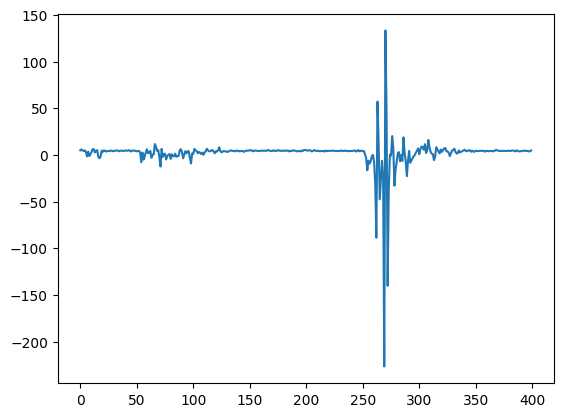

In [ ]:
plt.plot(lick[7800:8200,0])

In [ ]:
lick_times_behavior = detect_licking_events(lick[:,0], threshold=1.5, distance=3)

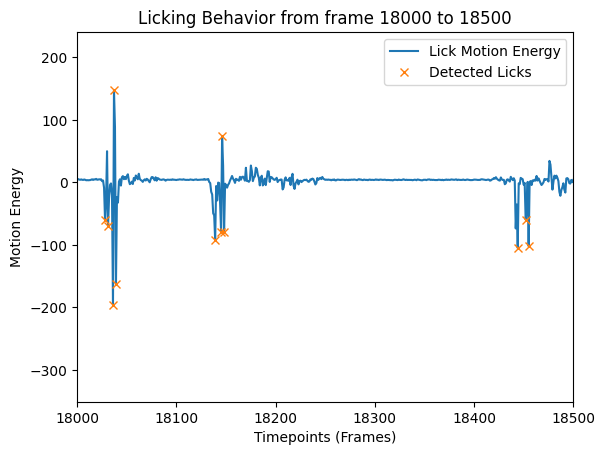

In [ ]:
start_frame = 18000
end_frame = 18500

# Plot the original signal
plt.plot(lick[:,0], label='Lick Motion Energy')

# Plot the detected peaks
plt.plot(lick_times_behavior, lick[lick_times_behavior, 0], "x", label='Detected Licks')

# Set the x-axis limits to zoom in
plt.xlim(start_frame, end_frame)

plt.xlabel("Timepoints (Frames)")
plt.ylabel("Motion Energy")
plt.title(f"Licking Behavior from frame {start_frame} to {end_frame}")
plt.legend()
plt.show()

In [ ]:
lick_times_behavior = detect_licking_events(lick[:,0], threshold=1.5, distance=3)
lick_times_behavior = lick_times_behavior + video_start
lick_times_sorted = np.sort(np.array(lick_times_behavior))

# Get the feedback times for rewarded trials (where feedbackType is 1).
rewarded_trials = table_for_video['feedbackType'] == 1
reward_feedback_times = table_for_video.loc[rewarded_trials, 'feedback_times'].values

# Find the corresponding consumption lick for each reward.
consumption_licks = find_first_event_after(lick_times_sorted, reward_feedback_times+10) # account for 10 frame delay

# Create the new column, initially all NaN.
table_for_video['reward_consume_times'] = np.nan

# Assign the found lick times back to the correct rows in the DataFrame.
table_for_video.loc[rewarded_trials, 'reward_consume_times'] = consumption_licks

In [ ]:
np.int16(consumption_licks-reward_feedback_times)

array([239,  30,  15,  12,  10,  13,  14,  18,  12,  15,  11,  10,  12,
        13, 126,  15,  24,  28,  32,  18, 236,  10,  14,  10,  95,  11,
        10,  24,  10,  10,  12,  10,  80, 216, 354,  10,  36,  11,  95,
        18,  13,  55,  13,  24,  11,  13,  10,  10,  12,  12,  95, 102,
        13,  12, 226,  10,  97, 110,  12,  99,  10,  22,  12,  10,  14,
        31,  22,  31,  11, 218,  11,  14, 111, 237,  13,  23, 262,  11,
        12,  12,  15,  18,  25,  24,  40,  14,  13,  13,  11, 105,  10,
        11, 213,  47,  21,  14,  15,  10,  11,  10,  41, 150,  12, 213,
        18,  14,  11,  11,  12,  10, 210,  17,  11,  10, 217, 208,  22,
        16, 308, 484, 142,  14,  13,  11,  10,  11,  10,  10,  29,  17,
       361,  12,  10,  10,  13,  12,  11,  12,  11,  11,  17,  17,  12,
        15,  10,  10,  14,  12,  15,  13,  12,  25,  13,  17,  18,  10,
        10,  12,  10,  13,  16,  11,  12, 128,  21,  10,  13,  15,  13,
        10,  15,  21,  37,  15,  11,  10,  10,  32,  12,  13], d

In [ ]:
np.where(consumption_licks-reward_feedback_times>30)[0]


array([  0,  14,  18,  20,  24,  32,  33,  34,  36,  38,  41,  50,  51,
        54,  56,  57,  59,  65,  67,  69,  72,  73,  76,  84,  89,  92,
        93, 100, 101, 103, 110, 114, 115, 118, 119, 120, 130, 163, 172,
       177], dtype=int64)

In [ ]:
table_for_video.to_csv(session_path+'\\table_for_video.csv', index=False)

In [ ]:
arm1_img_path = os.path.join(mouse_path, 'arm1')
arm1_table_for_img = pd.read_csv(arm1_img_path+'\\table_for_img.csv')

In [ ]:
arm1_img_start = arm1_table_for_img['ruleCue_times'][0]
arm1_img_end = arm1_table_for_img['intervals_1'].iloc[-1]
arm1_lick= zscore(downsample_array(lick,arm1_img_end-arm1_img_start,axis=0, method = 'interpolate'))
arm1_lick = arm1_lick+ np.min(arm1_lick[:,0])




In [ ]:
lick_times_arm1 = detect_licking_events(arm1_lick[:,0], threshold=0.5, distance=2)


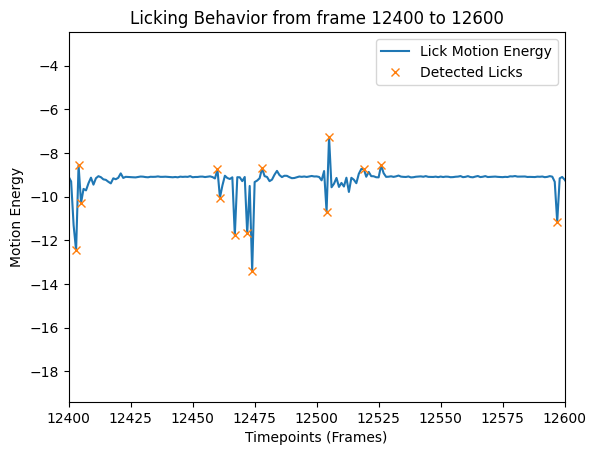

In [ ]:
start_frame = 12400
end_frame = 12600

# Plot the original signal
plt.plot(arm1_lick[:,0], label='Lick Motion Energy')

# Plot the detected peaks
plt.plot(lick_times_arm1, arm1_lick[lick_times_arm1, 0], "x", label='Detected Licks')

# Set the x-axis limits to zoom in
plt.xlim(start_frame, end_frame)

plt.xlabel("Timepoints (Frames)")
plt.ylabel("Motion Energy")
plt.title(f"Licking Behavior from frame {start_frame} to {end_frame}")
plt.legend()
plt.show()

In [ ]:
lick_times_arm1 = detect_licking_events(arm1_lick[:,0], threshold=0.5, distance=2)
lick_times_arm1 = lick_times_arm1 + arm1_img_start
lick_times_sorted = np.sort(np.array(lick_times_arm1))

# Get the feedback times for rewarded trials (where feedbackType is 1).
rewarded_trials = arm1_table_for_img['feedbackType'] == 1
reward_feedback_times = arm1_table_for_img.loc[rewarded_trials, 'feedback_times'].values

# Find the corresponding consumption lick for each reward.
consumption_licks = find_first_event_after(lick_times_sorted, reward_feedback_times+1)

# Create the new column, initially all NaN.
arm1_table_for_img['reward_consume_times'] = np.nan

# Assign the found lick times back to the correct rows in the DataFrame.
arm1_table_for_img.loc[rewarded_trials, 'reward_consume_times'] = consumption_licks

In [ ]:
consumption_licks-reward_feedback_times

array([  2.,   3.,   2.,   1.,   2.,   3.,   1.,   3.,   1.,   2.,   2.,
         1.,   2.,   3.,  26.,   4.,   4.,   6.,   7.,   4.,  61.,   1.,
         2.,   1.,  24.,   1.,   4.,   5.,   1.,   3.,   6.,   2.,  19.,
         1.,   9.,   2.,   6.,   4.,  22.,   2.,   3.,  12.,   2.,   4.,
         1.,   6.,   2.,   1.,   3.,   3.,   1.,   1.,   2.,   4., 112.,
         1.,  22.,  26.,   1.,   1.,   1.,   4.,   2.,   4.,   2.,   6.,
         2.,   2.,   3.,  53.,   3.,   3.,  25.,  59.,   1.,   6.,  65.,
         1.,   3.,   1.,   1.,   2.,   4.,   4.,   1.,   2.,   5.,   1.,
         1.,  27.,   4.,   3.,   2.,  12.,   1.,   2.,   1.,   5.,   1.,
         5.,   1.,   1.,   3.,  52.,   3.,   1.,   5.,   1.,   1.,   1.,
        51.,   4.,   2.,  50.,  55.,  51.,   4.,   2.,  79.,   3.,   2.,
         3.,   2.,   1.,   3.,   2.,   1.,   2.,   1.,   1.,  90.,   2.,
         4.,   2.,   4.,   2.,   1.,   7.,   1.,   2.,   1.,   3.,   2.,
         3.,   1.,   1.,   1.,   7.,   1.,   4.,   

In [ ]:
np.where(consumption_licks-reward_feedback_times>10)[0]

array([ 14,  20,  24,  32,  38,  41,  54,  56,  57,  69,  72,  73,  76,
        89,  93, 103, 110, 113, 114, 115, 118, 130, 163], dtype=int64)

In [ ]:
consumption_licks-reward_feedback_times

array([ 1.,  5.,  1.,  0., 42.,  0., 18.,  2.,  0., 24.,  0.,  1., 21.,
        0., 10.,  2.,  0.,  2., 27.,  2., 16., 11., 21., 45.,  5.,  2.,
        0.,  2., 36.,  0.,  0.,  2.,  0., 13.,  4.,  0.,  0.,  1.,  0.,
        2.,  0.,  0.,  1., 29.,  1.,  1.,  1.,  0., 26.,  4.,  0.,  1.,
        8.,  0.,  1.,  0.,  0.,  1.,  1.,  3.,  0.,  5.,  5.,  1.,  4.,
        8.,  2., 27.,  2.,  3.,  3.,  0.,  0.,  3., 35.,  3.,  6.,  0.,
        4.,  1.,  3.,  5.,  8.,  0.,  3.,  0.,  0.,  5., 33., 10.,  0.,
        1.,  0.,  3.,  4.,  1.,  3.,  7.,  3.,  0., 28.,  4.,  1., 36.,
        3.,  4.,  4.,  0., 23.,  0.,  0.,  4.,  0.,  0.,  6., 11., 64.,
        2.,  0.,  0.,  2.,  0.,  2.,  2.,  8., 44.,  3.,  0.,  1., 11.,
       24.,  8.,  0.,  7.,  1., 10.,  4.,  1., 38.,  2.,  6.,  5.,  7.,
        1.,  0.,  2.,  4.,  5.,  0., 46., 56., 29.,  0.,  3.,  7.,  3.,
        8.,  6.,  5.,  1.,  2.,  4., 31.,  6.,  1.,  3.,  1.,  2.,  3.,
        5.,  5.,  1.,  0.,  3., 62., 58.,  1.,  3.,  0.,  1.,  0

In [ ]:
reward_feedback_times[38]-arm1_img_start

5383

In [ ]:
arm1_table_for_img.to_csv(arm1_img_path+'\\table_for_img.csv', index=False)

In [ ]:
arm2_img_path = os.path.join(mouse_path, 'arm2')
arm2_table_for_img = pd.read_csv(arm2_img_path+'\\table_for_img.csv')

In [ ]:
arm2_img_start = arm2_table_for_img['ruleCue_times'][0]
arm2_img_end = arm2_table_for_img['intervals_1'].iloc[-1]
arm2_lick= zscore(downsample_array(lick,arm2_img_end-arm2_img_start,axis=0, method = 'interpolate'))
arm2_lick = arm2_lick+ np.min(arm2_lick[:,0])


In [ ]:
lick_times_arm2 = detect_licking_events(arm2_lick[:,0], threshold=0.5, distance=2)


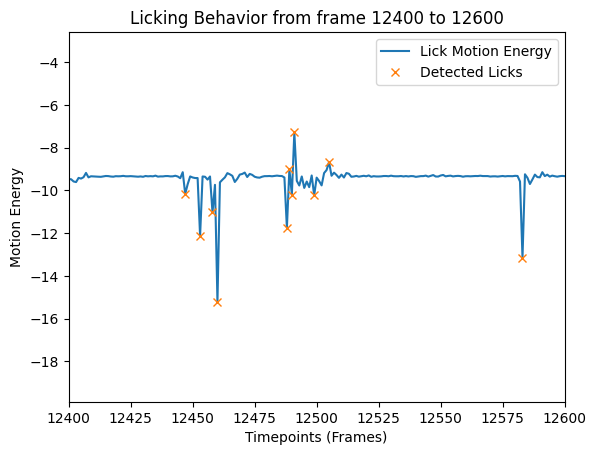

In [ ]:
start_frame = 12400
end_frame = 12600

# Plot the original signal
plt.plot(arm2_lick[:,0], label='Lick Motion Energy')

# Plot the detected peaks
plt.plot(lick_times_arm2, arm2_lick[lick_times_arm2, 0], "x", label='Detected Licks')

# Set the x-axis limits to zoom in
plt.xlim(start_frame, end_frame)

plt.xlabel("Timepoints (Frames)")
plt.ylabel("Motion Energy")
plt.title(f"Licking Behavior from frame {start_frame} to {end_frame}")
plt.legend()
plt.show()

In [ ]:
lick_times_arm2 = detect_licking_events(arm2_lick[:,0], threshold=0.5, distance=2)
lick_times_arm2 = lick_times_arm2 + arm2_img_start
lick_times_sorted = np.sort(np.array(lick_times_arm2))

# Get the feedback times for rewarded trials (where feedbackType is 1).
rewarded_trials = arm2_table_for_img['feedbackType'] == 1
reward_feedback_times = arm2_table_for_img.loc[rewarded_trials, 'feedback_times'].values

# Find the corresponding consumption lick for each reward.
consumption_licks = find_first_event_after(lick_times_sorted, reward_feedback_times+1)

# Create the new column, initially all NaN.
arm2_table_for_img['reward_consume_times'] = np.nan

# Assign the found lick times back to the correct rows in the DataFrame.
arm2_table_for_img.loc[rewarded_trials, 'reward_consume_times'] = consumption_licks

In [ ]:
consumption_licks-reward_feedback_times

array([ 8.,  2.,  3.,  1.,  3.,  4.,  1.,  2.,  2.,  2.,  1.,  3.,  1.,
        2.,  1.,  1.,  4.,  9.,  7.,  1., 60.,  1.,  3.,  3., 22.,  2.,
        1.,  5.,  1.,  1.,  4.,  3., 17., 53., 88.,  5.,  5.,  2., 22.,
        4.,  2., 12.,  5.,  5.,  1.,  3.,  4.,  3.,  3.,  3., 23.,  2.,
        1.,  1.,  1.,  1.,  3., 26.,  1.,  1.,  1.,  6.,  3.,  1.,  3.,
        9.,  1.,  3.,  2., 53.,  3.,  1.,  1.,  3.,  3.,  4.,  2.,  1.,
        1.,  2.,  2.,  1.,  1.,  5.,  1.,  1.,  1.,  1.,  2., 24.,  2.,
        2., 52., 12.,  1.,  1.,  5.,  1.,  1.,  3.,  1., 38.,  4., 52.,
        3.,  2.,  2.,  4.,  3.,  2., 51.,  2.,  1., 52., 55., 51.,  5.,
        3., 79.,  3.,  2.,  2.,  2.,  1.,  3.,  2.,  1.,  2.,  1.,  1.,
        2.,  2.,  3.,  2.,  6.,  5.,  3.,  3.,  1.,  5.,  2.,  1.,  5.,
        6.,  1.,  2.,  2.,  4.,  1.,  2.,  2.,  2.,  1.,  4.,  2.,  2.,
        3.,  1.,  1.,  1.,  4.,  2.,  2., 32.,  5.,  1.,  1.,  3.,  1.,
        2.,  4.,  2.,  3.,  4.,  2.,  4.,  4.,  3.,  1.,  1.])

In [ ]:
arm2_table_for_img.to_csv(arm2_img_path+'\\table_for_img.csv', index=False)

AUDIO

In [11]:
audio_filepath = os.path.join(session_path, 'raw_behavior_data', '_iblrig_micData.raw.wav')
sample_rate, audio_data = wavfile.read(audio_filepath)

In [12]:
sample_rate

200000

In [13]:
frequencies, times, Sxx = signal.spectrogram(audio_data, fs=sample_rate, nperseg=1024, noverlap=512)

# Limit the frequencies to 20k Hz (20000 Hz)
max_frequency = 20000
freq_limit = frequencies <= max_frequency

# Apply the frequency limit to the data
frequencies = frequencies[freq_limit]
Sxx = Sxx[freq_limit, :]



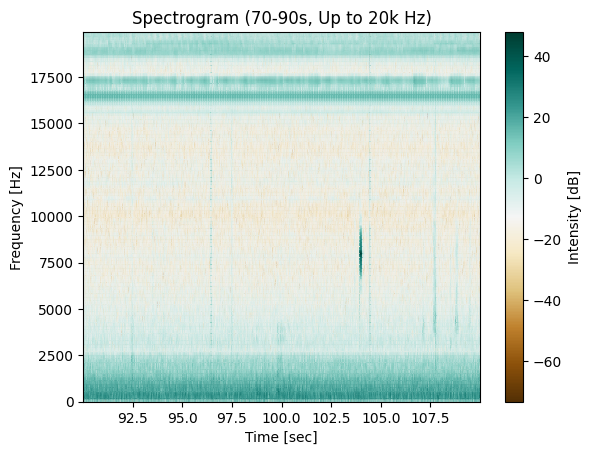

In [14]:
# Limit the time to the desired range (e.g., 70 to 90 seconds)
start_time = 90  # Start time in seconds
end_time = 110    # End time in seconds
time_limit = (times >= start_time) & (times <= end_time)

# Apply the time limit to the data
times = times[time_limit]
Sxx = Sxx[:, time_limit]

# Plot the spectrogram with the 'parula' colormap
plt.pcolormesh(times, frequencies, 10 * np.log10(Sxx), shading='gouraud', cmap='BrBG')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Spectrogram (70-90s, Up to 20k Hz)')
plt.colorbar(label='Intensity [dB]')
plt.show()

In [15]:
frequencies, times, Sxx = signal.spectrogram(audio_data, fs=sample_rate, nperseg=1024, noverlap=512)

# Convert the spectrogram to decibels for better visualization and peak detection
Sxx_dB = 10 * np.log10(Sxx)

In [20]:


# # Define your frequency bins (in Hz)
# frequency_bins = [
#     (5000, 8000),   # 5kHz to 8kHz
# ]

# # Initialize list to store the averaged intensities and detected peaks
# averaged_intensities = []
# peaks_in_bins = []

# # Loop through each frequency bin
# for freq_range in frequency_bins:
#     # Create a mask to select the frequencies within the current bin
#     freq_mask = (frequencies >= freq_range[0]) & (frequencies <= freq_range[1])

#     # Average the intensity across the selected frequency range (frequency axis)
#     avg_intensity = np.mean(Sxx_dB[freq_mask, :], axis=0)
    
#     # Find peaks in the averaged intensity across time
#     peaks, properties = signal.find_peaks(avg_intensity, height=20)  # Adjust 'height' as needed

#     # Store the results
#     averaged_intensities.append(avg_intensity)
#     peaks_in_bins.append(peaks)

# # Set a time difference threshold (in seconds)
# time_threshold = 0.2

# # Find consecutive peaks that are ~0.2s apart
# consecutive_peaks_times = []

# for peaks, freq_range in zip(peaks_in_bins, frequency_bins):
#     # Calculate the time difference between consecutive peaks
#     time_diffs = np.diff(times[peaks])
    
#     # Find pairs of peaks where the time difference is close to 0.2 seconds
#     consecutive_pairs = np.where((time_diffs >= time_threshold - 0.05) & (time_diffs <= time_threshold + 0.05))[0]
    
#     # For each pair, store the time of the first peak
#     for pair_idx in consecutive_pairs:
#         first_peak_time = times[peaks[pair_idx]]
#         consecutive_peaks_times.append(first_peak_time)

# # Output the times of occurrence of the first peak in each pair
# print("Times of first peaks in consecutive pairs ~0.2s apart:")
# print(consecutive_peaks_times)
# print(len(consecutive_peaks_times))

In [19]:
# # Step 1: Define the frequency range of interest (for example, 2kHz to 3kHz)
# min_frequency = 5000
# max_frequency = 15000

# # Step 2: Filter the frequencies to include only the desired range
# freq_mask = (frequencies >= min_frequency) & (frequencies <= max_frequency)

# # Step 3: Average the intensity over the selected frequency range
# avg_intensity_in_range = np.mean(Sxx_dB[freq_mask, :], axis=0)

# # Step 4: Find peaks in the averaged intensity across time
# peaks, properties = signal.find_peaks(avg_intensity_in_range, height=10)  # Adjust 'height' as needed

# # Step 5: Identify periods where peaks are exactly 0.1s apart
# peak_times = times[peaks]
# time_diffs = np.diff(peak_times)

# # Set threshold to find periods of exactly 0.1 seconds
# exact_duration = 0.1
# exact_peak_pairs = []

# # Look for pairs of peaks where the difference is exactly 0.1 seconds
# for i, time_diff in enumerate(time_diffs):
#     if abs(time_diff - exact_duration) <= 0.01:  # Allowing a small tolerance (0.01s)
#         exact_peak_pairs.append((peak_times[i], peak_times[i + 1]))

# # Output periods with peaks exactly 0.1 seconds apart
# print("Periods with peaks exactly 0.1 seconds apart:")
# for pair in exact_peak_pairs:
#     print(f"From {pair[0]:.2f}s to {pair[1]:.2f}s")

First peak in 12-15kHz range (within 10s) occurs at 0.15 seconds


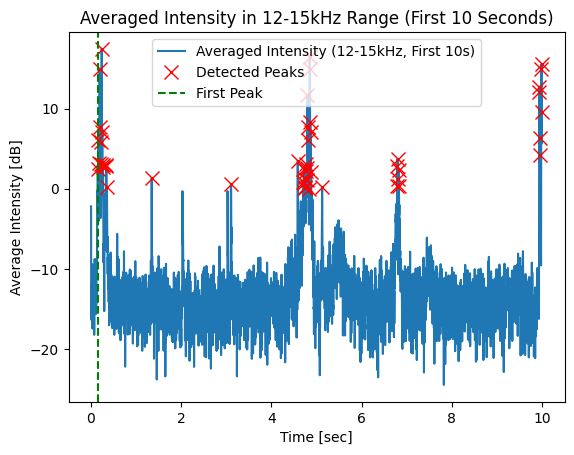

In [60]:
min_frequency = 7500
max_frequency = 8500

# Step 2: Filter the frequencies to include only the 12-15kHz range
freq_mask = (frequencies >= min_frequency) & (frequencies <= max_frequency)

# Step 3: Average the intensity over the selected frequency range (12-15kHz)
avg_intensity_12_15khz = np.mean(Sxx_dB[freq_mask, :], axis=0)

# Step 4: Limit to the first 10 seconds
time_limit = 10
time_mask = times <= time_limit

# Apply the time mask to the times and intensity
times_10sec = times[time_mask]
avg_intensity_12_15khz_10sec = avg_intensity_12_15khz[time_mask]

# Step 5: Find peaks in the averaged intensity for the first 10 seconds
peaks, properties = signal.find_peaks(avg_intensity_12_15khz_10sec, height=0)  # Adjust 'height' threshold as needed

# Step 6: Find the time of the first peak (if any peaks were found)
if len(peaks) > 0:
    first_peak_time = times_10sec[peaks[0]]  # Time of the first peak
    print(f"First peak in 12-15kHz range (within 10s) occurs at {first_peak_time:.2f} seconds")
else:
    print("No peaks found in the 12-15kHz range within the first 10 seconds")

# Plot only the first 10 seconds of averaged intensity and highlight the first peak
plt.plot(times_10sec, avg_intensity_12_15khz_10sec, label="Averaged Intensity (12-15kHz, First 10s)")
plt.plot(times_10sec[peaks], avg_intensity_12_15khz_10sec[peaks], 'rx', markersize=10, label="Detected Peaks")
if len(peaks) > 0:
    plt.axvline(x=first_peak_time, color='g', linestyle='--', label='First Peak')

plt.title('Averaged Intensity in 12-15kHz Range (First 10 Seconds)')
plt.xlabel('Time [sec]')
plt.ylabel('Average Intensity [dB]')
plt.legend()
plt.show()

In [56]:
print(np.sum(trials['table']['feedbackType']==1))
print(np.sum(trials['table']['feedbackType']==-1))

37
13


In [ ]:
# assert(len(consecutive_peaks_times)==np.sum(trials['table']['feedbackType']==1))

In [36]:
trials['table']

,intervals_0,intervals_1,ruleCue_times,ruleCueTrigger_times,feedback_times,feedbackType,rewardVolume,iti_dur,itiIn_times,trial_feedback_type
0,0.0000,8.738602,4.2075,4.1885,4.6885,1,0.5,4.0000,4.7385,1
1,8.7951,13.876502,8.8271,8.7951,9.2951,1,0.5,4.5313,9.3451,0
2,13.9356,20.562802,13.9667,13.9356,14.4356,1,0.5,6.0771,14.4856,0
3,20.6277,28.811402,20.6586,20.6277,21.1277,-1,0.0,7.6336,21.1777,-1
4,28.8806,34.490902,28.9106,28.8806,29.3806,1,0.5,5.0602,29.4306,1
5,34.6179,41.736302,34.6503,34.6179,35.1179,1,0.5,6.5683,35.1679,1
6,41.8009,49.509402,41.8382,41.8009,42.3009,1,0.5,7.1584,42.3509,1
7,49.5754,55.702603,49.6102,49.5754,50.0754,1,0.5,5.5771,50.1254,0
8,55.7655,62.243003,55.7980,55.7655,56.2655,1,0.5,5.9274,56.3155,0
9,62.3044,68.368502,62.3378,62.3044,62.8044,1,0.5,5.5140,62.8544,0


In [39]:
print(np.diff(trials['table'].loc[trials['table']['feedbackType']==1, 'feedback_times'])[:])
# print(np.diff(consecutive_peaks_times)[:])

[ 4.6066  5.1405 14.945   5.7373  7.183   7.7745  6.1901  6.5389  6.1286
 12.2781 19.7199  8.008  15.9963 13.2712  6.1448  7.5721  7.0032  7.224
 12.2643 13.7672  8.1019  6.1785  7.597   7.7495 20.0111  5.6162  6.0709
  8.3135 13.1607  6.3994  4.9789 13.0392  5.6334  4.7974 13.1966  8.0272]


In [40]:
rewardTrigger_times = np.array(trials['table'].loc[trials['table']['feedbackType']==1, 'feedback_times'])
# rewardValveSound_times = consecutive_peaks_times

In [58]:
first_peak_time

0.15104

In [43]:
# corrected_rewardValveSound_times = rewardValveSound_times + trials['table']['ruleCue_times'][0]-first_peak_time

# corrected_rewardValveSound_times

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 40, 41, 42, 43, 44, 45, 46, 46, 47, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 144, 145, 146, 148, 149, 150, 151, 152, 153, 154, 155, 156, 156, 158, 159, 160, 161, 163, 164, 165, 166, 167, 168, 169, 170, 171]


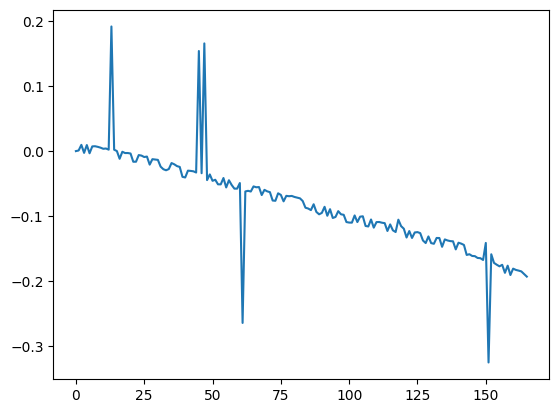

In [ ]:
# found_rewardValve_ind = [find_closest_index(corrected_rewardValveSound_times[i], rewardTrigger_times) for i in range(len(corrected_rewardValveSound_times))]
# print(found_rewardValve_ind)
# plt.plot(corrected_rewardValveSound_times-rewardTrigger_times[found_rewardValve_ind])

In [57]:
# print(corrected_rewardValveSound_times[160:])
# print(rewardTrigger_times[found_rewardValve_ind][160:])

In [61]:
bpod_trials[0]['behavior_data']['Events timestamps']

{'Port1In': [4.1885,
  4.205000000000001,
  4.221600000000001,
  4.2382,
  4.254700000000001,
  4.271299999999999,
  4.2878,
  4.3044,
  4.320900000000001,
  4.337500000000001,
  4.3541,
  4.3706000000000005,
  4.387199999999999,
  4.4037,
  4.4203,
  4.4369000000000005,
  4.453400000000001,
  4.4700000000000015,
  4.4865,
  4.503099999999999,
  4.519699999999999,
  4.5362,
  4.5528,
  4.569300000000001,
  4.585900000000001,
  4.6025,
  4.619000000000001,
  4.635599999999999,
  4.6521,
  4.6687,
  4.685300000000001,
  4.701800000000001,
  4.7184,
  4.7349000000000006,
  4.751499999999999,
  4.7681,
  4.7846,
  4.801200000000001,
  4.817700000000001,
  4.8343,
  4.8509,
  4.867399999999999,
  4.8839999999999995,
  4.9005,
  4.9171000000000005,
  4.933700000000001,
  4.9502000000000015,
  4.9668,
  4.983299999999999,
  4.999899999999999,
  5.0165,
  5.033,
  5.049600000000001,
  5.066100000000001,
  5.0827,
  5.099200000000001,
  5.115799999999999,
  5.1324,
  5.1489,
  5.165500000000001

In [62]:
cam_frame_data

,Timestamp,embeddedTimeStamp,embeddedFrameCounter,embeddedGPIOPinState
0,0.000000,0.000000,0,"[False, True, False, True]"
1,0.032730,0.033125,2,"[False, True, False, False]"
2,0.039142,0.049625,3,"[False, True, False, False]"
3,0.055411,0.066250,4,"[False, True, False, False]"
4,0.071987,0.082750,5,"[False, True, False, False]"
...,...,...,...,...
20494,339.455014,339.429625,20497,"[False, True, False, True]"
20495,339.470925,339.446125,20498,"[False, True, False, True]"
20496,339.488243,339.462750,20499,"[False, True, False, True]"
20497,339.504128,339.479250,20500,"[False, True, False, True]"


In [ ]:
# base = [CameraTimestampsBpod]

# settings = rawio.load_settings(cam_session_path, task_collection='raw_behavior_data')
# out, fil = run_extractor_classes(base, save=False, session_path=cam_session_path, bpod_trials=bpod_trials, settings=settings,
#                                      task_collection='raw_behavior_data')

In [47]:
cam_start_bpod_time = bpod_trials[0]['behavior_data']['Events timestamps']['Port1In'][0]-bpod_trials[0]['behavior_data']['Trial start timestamp']
cam_start_bpod_time

4.1885

In [46]:
trials['table']

,intervals_0,intervals_1,ruleCue_times,ruleCueTrigger_times,feedback_times,feedbackType,rewardVolume,iti_dur,itiIn_times,trial_feedback_type
0,0.0000,8.738602,4.2075,4.1885,4.6885,1,0.5,4.0000,4.7385,1
1,8.7951,13.876502,8.8271,8.7951,9.2951,1,0.5,4.5313,9.3451,0
2,13.9356,20.562802,13.9667,13.9356,14.4356,1,0.5,6.0771,14.4856,0
3,20.6277,28.811402,20.6586,20.6277,21.1277,-1,0.0,7.6336,21.1777,-1
4,28.8806,34.490902,28.9106,28.8806,29.3806,1,0.5,5.0602,29.4306,1
5,34.6179,41.736302,34.6503,34.6179,35.1179,1,0.5,6.5683,35.1679,1
6,41.8009,49.509402,41.8382,41.8009,42.3009,1,0.5,7.1584,42.3509,1
7,49.5754,55.702603,49.6102,49.5754,50.0754,1,0.5,5.5771,50.1254,0
8,55.7655,62.243003,55.7980,55.7655,56.2655,1,0.5,5.9274,56.3155,0
9,62.3044,68.368502,62.3378,62.3044,62.8044,1,0.5,5.5140,62.8544,0


In [48]:
def find_closest_index(value, list_of_values):
    # Find the index of the closest value in list_of_values
    return np.abs(np.array(list_of_values) - value).argmin()

table_for_video = trials['table'].copy()
for col in table_for_video.columns:
    if 'times' in col or 'intervals' in col:
        table_for_video[col] = table_for_video[col].subtract(cam_start_bpod_time)
        table_for_video[col] = table_for_video[col].apply(lambda x: embed_frame_counter[find_closest_index(x, embed_ts)])
table_for_video

,intervals_0,intervals_1,ruleCue_times,ruleCueTrigger_times,feedback_times,feedbackType,rewardVolume,iti_dur,itiIn_times,trial_feedback_type
0,0,275,2,0,30,1,0.5,4.0000,33,1
1,278,585,280,278,308,1,0.5,4.5313,311,0
2,589,989,590,589,619,1,0.5,6.0771,622,0
3,993,1487,995,993,1023,-1,0.0,7.6336,1026,-1
4,1491,1830,1493,1491,1521,1,0.5,5.0602,1524,1
5,1838,2267,1839,1838,1868,1,0.5,6.5683,1871,1
6,2271,2737,2274,2271,2301,1,0.5,7.1584,2305,1
7,2741,3111,2743,2741,2771,1,0.5,5.5771,2774,0
8,3115,3506,3117,3115,3145,1,0.5,5.9274,3148,0
9,3509,3876,3511,3509,3540,1,0.5,5.5140,3543,0


In [49]:
#valid_trials = np.arange(0,314)
valid_trials = np.arange(0,len(trials['table']))
table_for_video = table_for_video.iloc[valid_trials]
table_for_video

,intervals_0,intervals_1,ruleCue_times,ruleCueTrigger_times,feedback_times,feedbackType,rewardVolume,iti_dur,itiIn_times,trial_feedback_type
0,0,275,2,0,30,1,0.5,4.0000,33,1
1,278,585,280,278,308,1,0.5,4.5313,311,0
2,589,989,590,589,619,1,0.5,6.0771,622,0
3,993,1487,995,993,1023,-1,0.0,7.6336,1026,-1
4,1491,1830,1493,1491,1521,1,0.5,5.0602,1524,1
5,1838,2267,1839,1838,1868,1,0.5,6.5683,1871,1
6,2271,2737,2274,2271,2301,1,0.5,7.1584,2305,1
7,2741,3111,2743,2741,2771,1,0.5,5.5771,2774,0
8,3115,3506,3117,3115,3145,1,0.5,5.9274,3148,0
9,3509,3876,3511,3509,3540,1,0.5,5.5140,3543,0


In [50]:
table_for_video.to_csv(cam_session_path+'\\table_for_video.csv', index=False)
table_for_video


,intervals_0,intervals_1,ruleCue_times,ruleCueTrigger_times,feedback_times,feedbackType,rewardVolume,iti_dur,itiIn_times,trial_feedback_type
0,0,275,2,0,30,1,0.5,4.0000,33,1
1,278,585,280,278,308,1,0.5,4.5313,311,0
2,589,989,590,589,619,1,0.5,6.0771,622,0
3,993,1487,995,993,1023,-1,0.0,7.6336,1026,-1
4,1491,1830,1493,1491,1521,1,0.5,5.0602,1524,1
5,1838,2267,1839,1838,1868,1,0.5,6.5683,1871,1
6,2271,2737,2274,2271,2301,1,0.5,7.1584,2305,1
7,2741,3111,2743,2741,2771,1,0.5,5.5771,2774,0
8,3115,3506,3117,3115,3145,1,0.5,5.9274,3148,0
9,3509,3876,3511,3509,3540,1,0.5,5.5140,3543,0


In [51]:
np.diff(np.array(trials['table']['ruleCue_times']))

array([4.6196, 5.1396, 6.6919, 8.252 , 5.7397, 7.1879, 7.772 , 6.1878,
       6.5398, 6.1278, 5.7877, 6.4878, 5.5997, 7.848 , 6.2758, 8.008 ,
       8.4961, 7.4999, 7.2439, 6.0278, 6.1437, 7.572 , 6.9999, 7.2279,
       7.5209, 4.7436, 5.6597, 8.108 , 8.101 , 6.1808, 7.596 , 7.7479,
       6.6239, 7.9   , 5.4887, 5.6117, 6.0717, 8.3201, 5.1716, 7.984 ,
       6.3998, 4.9757, 6.2277, 6.8119, 5.6357, 4.7996, 6.6718, 6.5238,
       8.0241])

In [52]:
trials['table']

,intervals_0,intervals_1,ruleCue_times,ruleCueTrigger_times,feedback_times,feedbackType,rewardVolume,iti_dur,itiIn_times,trial_feedback_type
0,0.0000,8.738602,4.2075,4.1885,4.6885,1,0.5,4.0000,4.7385,1
1,8.7951,13.876502,8.8271,8.7951,9.2951,1,0.5,4.5313,9.3451,0
2,13.9356,20.562802,13.9667,13.9356,14.4356,1,0.5,6.0771,14.4856,0
3,20.6277,28.811402,20.6586,20.6277,21.1277,-1,0.0,7.6336,21.1777,-1
4,28.8806,34.490902,28.9106,28.8806,29.3806,1,0.5,5.0602,29.4306,1
5,34.6179,41.736302,34.6503,34.6179,35.1179,1,0.5,6.5683,35.1679,1
6,41.8009,49.509402,41.8382,41.8009,42.3009,1,0.5,7.1584,42.3509,1
7,49.5754,55.702603,49.6102,49.5754,50.0754,1,0.5,5.5771,50.1254,0
8,55.7655,62.243003,55.7980,55.7655,56.2655,1,0.5,5.9274,56.3155,0
9,62.3044,68.368502,62.3378,62.3044,62.8044,1,0.5,5.5140,62.8544,0


In [ ]:
facemap_proc = np.load(os.path.join(r'I:\A_R2\20240821\behavior\raw_video_data', r'_iblrig_leftCamera.raw_proc.npy' ), allow_pickle=True)

In [ ]:
facemap_proc.shape

()